<h1 class="red-border">Comparaison of Clustering Methods</h1>

In [3]:
import importlib
import subprocess
import sys

# Dictionnaire des bibliothèques nécessaires
# Format : "nom_module_import": "nom_paquet_pip"
required_packages = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "minisom": "minisom",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "scipy": "scipy"
}

def install_and_import():
    print("🔍 Analyse de l'environnement de travail...")
    for module_name, package_name in required_packages.items():
        try:
            importlib.import_module(module_name)
            print(f"✅ {module_name} est déjà prêt.")
        except ImportError:
            print(f"⚠️ {module_name} manque. Installation de {package_name} en cours...")
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
                print(f"🚀 {package_name} installé avec succès !")
            except Exception as e:
                print(f"❌ Erreur lors de l'installation de {package_name} : {e}")

# Lancement de la vérification/installation
install_and_import()

# Importations générales
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from minisom import MiniSom  

# Scikit-learn : Prétraitement et Réduction de dimension
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.neighbors import NearestNeighbors

# Scikit-learn : Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Scikit-learn : Métriques d'évaluation
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

# Configuration optionnelle
warnings.filterwarnings('ignore')

print("\n✨ Toutes les bibliothèques de clustering et d'analyse sont prêtes !")

🔍 Analyse de l'environnement de travail...
✅ numpy est déjà prêt.
✅ matplotlib est déjà prêt.
✅ minisom est déjà prêt.
✅ pandas est déjà prêt.
✅ sklearn est déjà prêt.
✅ scipy est déjà prêt.

✨ Toutes les bibliothèques de clustering et d'analyse sont prêtes !


## Preprocessing and Data Quality (Hopkins Score)
### 1.a Hopkins Score

In [4]:
def hopkins_statistic(X, m_ratio=0.1):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    d = X.shape[1]
    n = len(X)
    m = int(m_ratio * n)

    rand_X = X.sample(m)
    neigh = NearestNeighbors(n_neighbors=1).fit(X)

    u_dist, _ = neigh.kneighbors(rand_X)

    min_vals, max_vals = X.min(), X.max()
    rand_uniform = np.random.uniform(low=min_vals, high=max_vals, size=(m, d))
    w_dist, _ = neigh.kneighbors(rand_uniform)

    return np.sum(w_dist) / (np.sum(u_dist) + np.sum(w_dist))

### 1.b Evaluation metric

In [5]:
def evaluate_clustering(X, labels):
    unique = set(labels) - {-1}  # exclude DBSCAN noise points
    if len(unique) <= 1:
        return np.nan, np.nan, np.nan

    return (
        silhouette_score(X, labels),
        davies_bouldin_score(X, labels),
        calinski_harabasz_score(X, labels)
    )

#### Stability (ARI)

The data is resampled using 80% bootstrapping across multiple runs. Rather than naively truncating label arrays, which would compare labels from different cells, each run tracks the indices of the sampled cells. The ARI is then computed only on cells that appear in both runs, ensuring a meaningful comparison between partitionings while adjusting for chance.

In [6]:
def compute_stability(X, model, n_runs=5):
    if not isinstance(X, np.ndarray):
        X = np.array(X)

    n = len(X)
    labels_list = []
    indices_list = []

    for i in range(n_runs):
        idx = resample(np.arange(n), n_samples=int(0.8 * n), random_state=42 + i, replace=False)
        X_sample = X[idx]

        if isinstance(model, GaussianMixture):
            labels = model.fit(X_sample).predict(X_sample)
        else:
            labels = model.fit_predict(X_sample)

        labels_list.append(labels)
        indices_list.append(idx)

    ari_scores = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            common = np.intersect1d(indices_list[i], indices_list[j])
            if len(common) < 2:
                continue
            pos_i = np.where(np.isin(indices_list[i], common))[0]
            pos_j = np.where(np.isin(indices_list[j], common))[0]
            ari = adjusted_rand_score(
                labels_list[i][pos_i],
                labels_list[j][pos_j]
            )
            ari_scores.append(ari)

    return np.mean(ari_scores) if ari_scores else np.nan

### 1.c Automatic K calculation

We use a `KMeans` algorithm for each possible value of k.

For each $k$, the three metrics are calculated. Since the score results are on different scales, the Davies-Bouldin index is inverted. We multiply it by $-1$ because for Silhouette and CH, 'higher is better,' whereas for DB, 'lower is better.' By inverting it, the metrics are harmonized: a higher value becomes better for all three. Finally, all values are normalized to a range between 0 and 1. This ensures that each index carries the same weight in the final decision.

We calculate the average of the 3 normalized indices and retrieve the corresponding value of k.

In [7]:
def find_best_k(X, k_range):
    results = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)

        sil, db, ch = evaluate_clustering(X, labels)

        results.append([k, sil, db, ch])

    df = pd.DataFrame(results, columns=["k", "sil", "db", "ch"])

    # Normalisation
    scaler = MinMaxScaler()
    scores = df[["sil", "db", "ch"]].copy()
    scores["db"] = -scores["db"]
    scores_scaled = scaler.fit_transform(scores)

    df["score"] = scores_scaled.mean(axis=1)

    best_k = df.loc[df["score"].idxmax(), "k"]

    return int(best_k), df




## Data Application
### 2.a Data loading and normalization

In [8]:
data = pd.read_csv("Cluster_ImmuneCell.csv")
X = data.select_dtypes(include=['float64', 'int64'])

hopkins_before = hopkins_statistic(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

hopkins_after = hopkins_statistic(pd.DataFrame(X_scaled, columns=X.columns))

print(f'Hopkins avant : {hopkins_before:.3f}')
print(f'Hopkins après : {hopkins_after:.3f}')

X_best = X_scaled if hopkins_after > hopkins_before else X.values

Hopkins avant : 1.000
Hopkins après : 1.000


### 2.b Data reduction (PCA) and k selection

Once the Hopkins test has validated the presence of clusters, the data is simplified. We compress the markers to retain only those that explain 90% of the variance. This allows us to eliminate background sensor noise before proceeding to computationally intensive models.

In [9]:
pca = PCA(n_components=0.9)
X_reduced = pca.fit_transform(X_best)

print(f"📐 PCA components retained : {pca.n_components_} (90% of variance explained)")

k_range = range(2, 10)
optimal_k, k_results = find_best_k(X_reduced, k_range)

print(f"\n👉 Optimal k detected : {optimal_k}")

📐 PCA components retained : 9 (90% of variance explained)

👉 Optimal k detected : 2


### 2.c Benchmarking of models

In [10]:
# Automatic eps estimation for DBSCAN using k-distance elbow method
neighbors = NearestNeighbors(n_neighbors=5).fit(X_reduced)
distances, _ = neighbors.kneighbors(X_reduced)
k_distances = np.sort(distances[:, -1])
eps_auto = float(np.percentile(k_distances, 90))

print(f"📐 DBSCAN eps estimated : {eps_auto:.3f}")

clustering_methods = {
    'KMeans': KMeans(n_clusters=optimal_k, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=optimal_k),
    'Spectral': SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', random_state=42),
    'GMM': GaussianMixture(n_components=optimal_k, random_state=42),
    'DBSCAN': DBSCAN(eps=eps_auto, min_samples=5)
}

📐 DBSCAN eps estimated : 3.885


## 3. Evaluation of results

In [17]:
results = []
labels_per_method = {}

for name, model in clustering_methods.items():
    print(f"⏳ Running {name}...")

    try:
        if name == "GMM":
            labels = model.fit(X_reduced).predict(X_reduced)
        else:
            labels = model.fit_predict(X_reduced)

        sil, db, ch = evaluate_clustering(X_reduced, labels)
        stability = compute_stability(X_reduced, model)
        labels_per_method[name] = labels
        print(f"✅ {name} done.")

    except Exception as e:
        print(f"❌ Error {name}: {e}")
        sil, db, ch, stability = np.nan, np.nan, np.nan, np.nan
        labels_per_method[name] = None

    results.append({
        "Method": name,
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch,
        "Stability (ARI)": stability
    })

results_df = pd.DataFrame(results)

⏳ Running KMeans...
✅ KMeans done.
⏳ Running Agglomerative...
✅ Agglomerative done.
⏳ Running Spectral...
✅ Spectral done.
⏳ Running GMM...
✅ GMM done.
⏳ Running DBSCAN...
✅ DBSCAN done.


In [12]:
print(results_df.to_string(index=False))

       Method  Silhouette  Davies-Bouldin  Calinski-Harabasz  Stability (ARI)
       KMeans    0.571333        1.187800          23.941485        -0.017331
Agglomerative    0.302643        2.067349          21.007333        -0.011422
     Spectral    0.172834        2.035259          19.181199        -0.006495
          GMM    0.360856        2.245315          15.276972        -0.010481
       DBSCAN         NaN             NaN                NaN         0.035583


## 4. Visualization and optimal algorithm

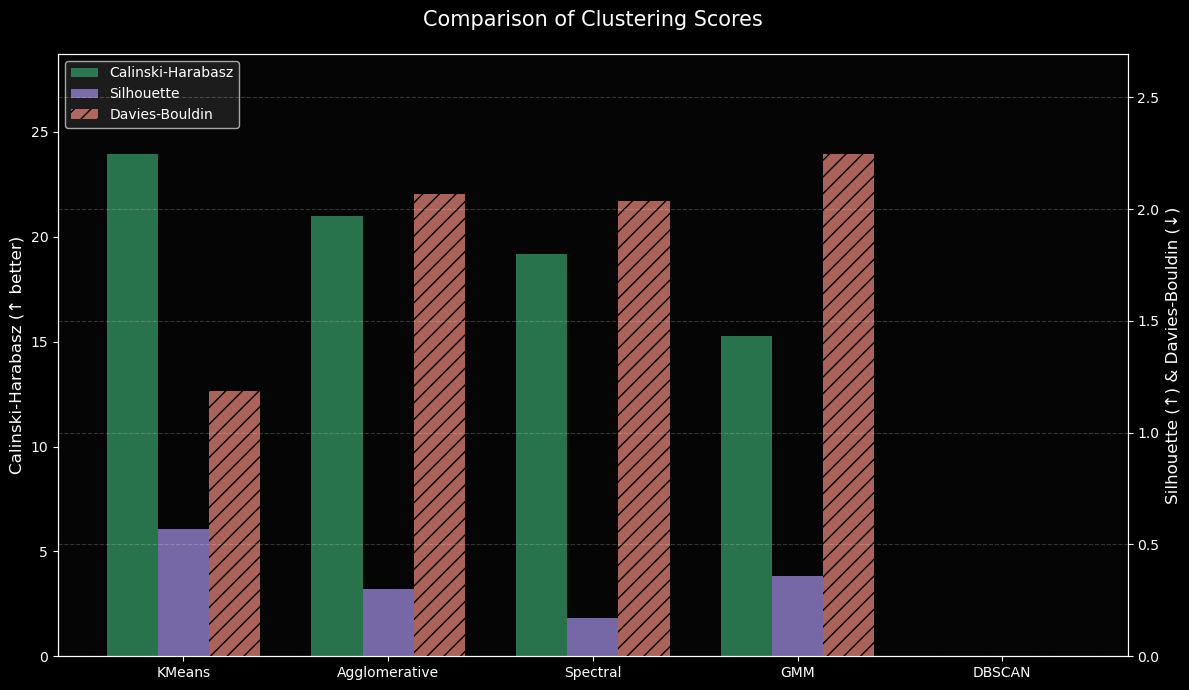


--- Summary table ---
       Method  Silhouette  Davies-Bouldin  Global_Score
       KMeans    0.571333        1.187800      0.617747
Agglomerative    0.302643        2.067349      0.399522
     Spectral    0.172834        2.035259      0.350506
          GMM    0.360856        2.245315      0.349786
       DBSCAN         NaN             NaN      0.500000

🏆 The recommended algorithm for your MACSima data is : KMeans


In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('dark_background')

methods = results_df['Method']
x = np.arange(len(methods))
width = 0.25

fig, ax1 = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#000000')
ax1.set_facecolor('#050505')

# First Y axis : Calinski-Harabasz
ch_values = results_df['Calinski-Harabasz'].fillna(0)
rects1 = ax1.bar(x - width, ch_values, width,
                 label='Calinski-Harabasz', color='#31905e', alpha=0.8)

ax1.set_ylabel('Calinski-Harabasz (↑ better)', color='white', fontsize=12)
ax1.tick_params(axis='y', labelcolor='white')
ax1.set_ylim(0, ch_values.max() * 1.2 if ch_values.max() > 0 else 100)

# Second Y axis : Silhouette & Davies-Bouldin
ax2 = ax1.twinx()
sil_values = results_df['Silhouette'].fillna(0)
db_values = results_df['Davies-Bouldin'].fillna(0)

rects2 = ax2.bar(x, sil_values, width,
                 label='Silhouette', color='#9381cf', alpha=0.8)
rects3 = ax2.bar(x + width, db_values, width,
                 label='Davies-Bouldin', color='#d67b6f', hatch='//', alpha=0.8)

ax2.set_ylabel('Silhouette (↑) & Davies-Bouldin (↓)', color='white', fontsize=12)
ax2.tick_params(axis='y', labelcolor='white')
ax2.set_ylim(0, max(sil_values.max(), db_values.max()) * 1.2 if max(sil_values.max(), db_values.max()) > 0 else 1.5)

# Title & Legend
plt.title("Comparison of Clustering Scores", color='white', fontsize=15, pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, color='white')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, facecolor='#222')

plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

# ------------------- BEST METHOD SELECTION -------------------

scaler = MinMaxScaler()

scores_to_rank = results_df[['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'Stability (ARI)']].copy()
scores_to_rank = scores_to_rank.fillna(0)

# DB is inverted so that higher is consistently better across all metrics
scores_to_rank['Davies-Bouldin'] = -scores_to_rank['Davies-Bouldin']

# Normalization between 0 and 1 so each metric carries equal weight
scores_scaled = scaler.fit_transform(scores_to_rank)
results_df['Global_Score'] = scores_scaled.mean(axis=1)

best_method = results_df.loc[results_df['Global_Score'].idxmax(), 'Method']
best_labels = labels_per_method[best_method]

print("\n--- Summary table ---")
print(results_df[['Method', 'Silhouette', 'Davies-Bouldin', 'Global_Score']].to_string(index=False))

print(f"\n🏆 The recommended algorithm for your MACSima data is : {best_method}")

plt.style.use('default')

L'absence de données pour l'algorithme DBSCAN s'explique par sa différence fondamentale de fonctionnement par rapport aux modèles basés sur les centroïdes (comme KMeans). Contrairement à ces derniers qui forcent chaque point à appartenir à un groupe, DBSCAN est un algorithme basé sur la densité. Il nécessite deux paramètres cruciaux : le rayon de recherche (eps) et le nombre minimum de points (min_samples). Si ces paramètres sont trop restrictifs par rapport à la distribution spatiale des données — notamment après une réduction de dimension (PCA) qui modifie les distances — l'algorithme peut classer la totalité des points comme du "bruit" (outliers). Mathématiquement, si aucun cluster n'est formé ou si un seul groupe global est identifié, les métriques de validation (Silhouette, Davies-Bouldin, Calinski-Harabasz) ne peuvent pas être calculées, car elles nécessitent la comparaison d'au moins deux partitions distinctes. Dans un contexte de biologie tissulaire, cela arrive souvent lorsque la densité cellulaire est trop hétérogène pour être capturée par un rayon de recherche unique et fixe.

## 5. Marker Expression Heatmap

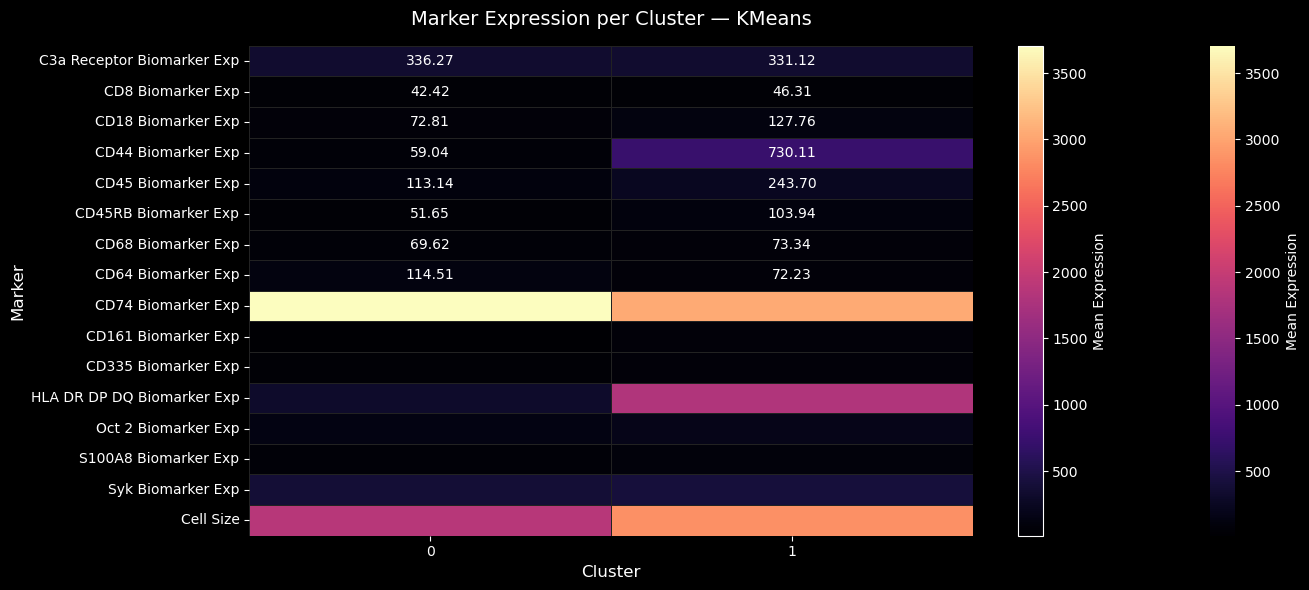

In [20]:
# ------------------- HEATMAP -------------------
import seaborn as sns

# Ajouter les labels au DataFrame original
df_heatmap = X.copy()
df_heatmap['Cluster'] = best_labels

# Exclure le bruit DBSCAN si présent
df_heatmap = df_heatmap[df_heatmap['Cluster'] != -1]

# Moyenne des marqueurs par cluster
cluster_means = df_heatmap.groupby('Cluster').mean()

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#050505')

sns.heatmap(
    cluster_means.T,
    ax=ax,
    cmap='magma',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='#222',
    cbar_kws={'label': 'Mean Expression'}
)

ax.set_title(f"Marker Expression per Cluster — {best_method}", 
             color='white', fontsize=14, pad=15)
ax.set_xlabel('Cluster', color='white', fontsize=12)
ax.set_ylabel('Marker', color='white', fontsize=12)
ax.tick_params(colors='white')
plt.colorbar(ax.collections[0]).set_label('Mean Expression', color='white')
plt.tight_layout()
plt.show()

plt.style.use('default')